In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 소셜 광고 데이터 셋
[소셜 광고 데이터셋 링크](https://www.kaggle.com/datasets/akram24/social-network-ads?resource=download)

### 소셜 광고 데이터 셋 컬럼
| 컬럼명 (Column) | 데이터 타입 | 설명 (Description) |
| :--- | :--- | :--- |
| **User ID** | 정수형 (Int) | 유저 고유 식별 번호 (학습 시 제외) |
| **Gender** | 문자형 (String) | 유저의 성별 (Male / Female) |
| **Age** | 정수형 (Int) | 유저의 나이 |
| **EstimatedSalary** | 정수형 (Int) | 유저의 추정 연봉 |
| **Purchased** | 정수형 (Int) | 광고 물건 구매 여부 (0: 미구매, 1: 구매)|

In [2]:
base_path=r'C:\kdt_0900_ojh\ml\resource\dataset'
file_name=r'social_ads.csv'
file_path=os.path.join(base_path,file_name)

In [3]:
df=pd.read_csv(file_path)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


## 1단계, 데이터 전처리

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [5]:
# User ID: 삭제
# 수치형: Age, EstimatedSalary
# 분류형: User ID, Gender, Purchased
df.info

<bound method DataFrame.info of       User ID  Gender  Age  EstimatedSalary  Purchased
0    15624510    Male   19            19000          0
1    15810944    Male   35            20000          0
2    15668575  Female   26            43000          0
3    15603246  Female   27            57000          0
4    15804002    Male   19            76000          0
..        ...     ...  ...              ...        ...
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1

[400 rows x 5 columns]>

In [6]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [7]:
ads_df = df.drop('User ID', axis=1)
ads_df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [8]:
ads_df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

<Axes: xlabel='Purchased', ylabel='EstimatedSalary'>

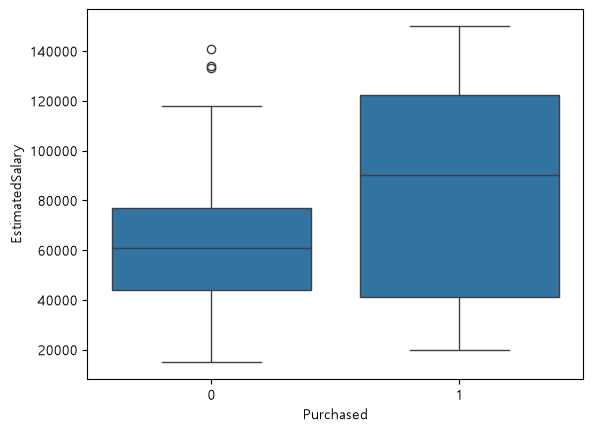

In [9]:
sns.boxplot(ads_df, x='Purchased', y='EstimatedSalary')

<Axes: xlabel='Purchased', ylabel='Age'>

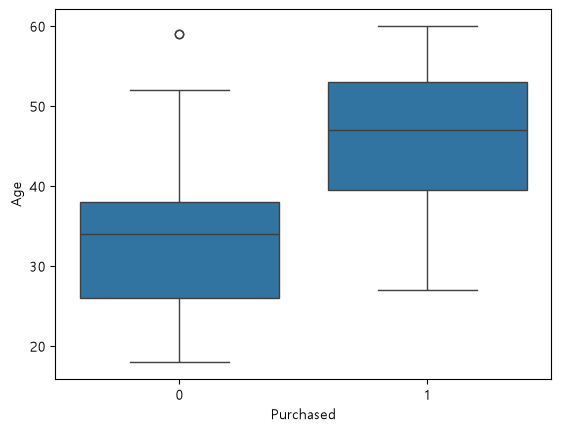

In [10]:
sns.boxplot(ads_df, x='Purchased', y='Age')

In [11]:
ads_df = pd.get_dummies(ads_df, columns=['Gender'], dtype=int, drop_first=True)

In [12]:
X=ads_df.drop('Purchased', axis=1)
X.head(1)

,Age,EstimatedSalary,Gender_Male
0,19,19000,1


In [13]:
y=ads_df['Purchased']
y.head(1)

0    0
Name: Purchased, dtype: int64

In [14]:
X.columns=['Age','Salary','Gender']

In [15]:
X.head()

,Age,Salary,Gender
0,19,19000,1
1,35,20000,1
2,26,43000,0
3,27,57000,0
4,19,76000,1


## 데이터 누수
- 데이터 셋을 나누고 스케일링을 해야하는 이유 -> 데이터 셋을 나누기 전에 전체 데이타를 스케일링하면  
  모델 학습 전에 학습시 절대 보면 안되는 테스트 데이터의 평균과 숫자들이 훈련 데이터셋에 야금야금 스며들어서 데이터 누수가 발생한다.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, stratify=y, random_state=2026)

In [17]:
# 1. 자르고 표준화한다
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_salary= X_train_scaled[:,[1]]
X_test_salary= X_test_scaled[:,[1]]

In [19]:
# Weight: 가중치
# bias: 절편
lr=LinearRegression()

In [20]:
lr.fit(X_train_salary, y_train)

LinearRegression()

In [21]:
print(lr.score(X_train_salary, y_train))

0.1408930349620512


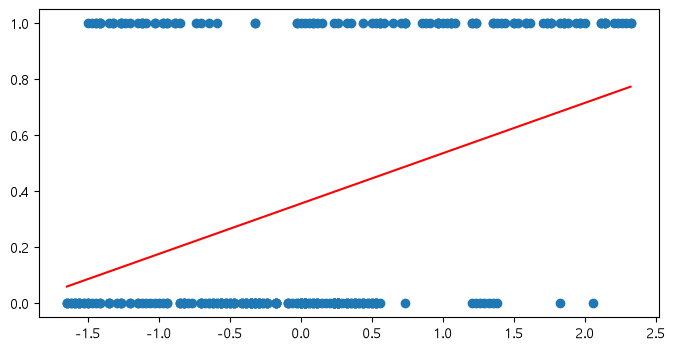

In [22]:
plt.figure(figsize=(8,4))
plt.scatter(X_train_salary, y_train)
x_line = np.linspace(X_train_salary.min(), X_train_salary.max(), 100).reshape(-1,1)
y_line = lr.predict(x_line)
plt.plot(x_line, y_line, color='red')

## 모델 준비

In [23]:
lr = LogisticRegression()

In [24]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [25]:
y_pred = lr.predict(X_test_scaled)
y_pred

array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0])

## 모델 평가
<img src="https://blog.kakaocdn.net/dna/beQKaR/btsQVxmfALT/AAAAAAAAAAAAAAAAAAAAAEN8Msuz4492U5M2pBZKQ2RtjEOY5OdH6q0btxI5Uurb/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1790780399&allow_ip=&allow_referer=&signature=7GgzV35irLeFkyH%2BGmsM6uW65LQ%3D" />

### 과적합(overfitting)
- 머신러닝 과적합은 모델이 학습 데이터에만 지난치게 최적화 되는 현상을 의미합니다.  
  현재 데이터셋에 지나치게 맞춰지게 되면, 새로운 데이터가 들어왔을 때 예측 능력이 크게 떨어질 수 있습니다.  
  이런 현상을 과적합이라고 합니다.

In [26]:
print(lr.score(X_train_scaled, y_train))
print(accuracy_score(y_test, y_pred))

0.853125
0.7875


In [27]:
coef_df = pd.DataFrame({
    'Features':X_train.columns,
    'Coef': lr.coef_[0]
}).sort_values(by='Coef', ascending=False)
coef_df

,Features,Coef
0,Age,2.394875
1,Salary,1.161530
2,Gender,0.373889


<Axes: xlabel='Features', ylabel='Coef'>

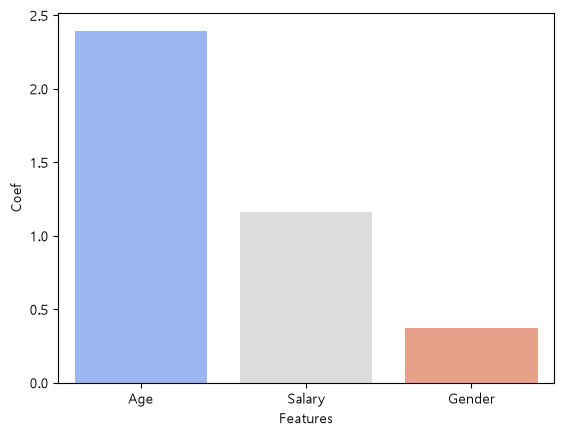

In [28]:
sns.barplot(coef_df, x='Features', y='Coef', hue='Features', palette='coolwarm')


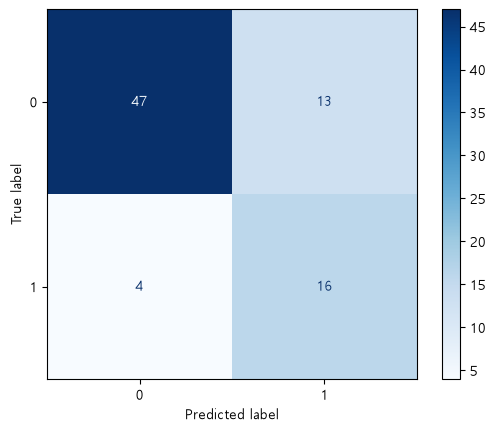

In [29]:
cm = confusion_matrix(y_pred, y_test)
display=ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap='Blues')
plt.show()

# 대학원 합격 예측 데이터 셋
[대학원 합격 예측 데이터셋 링크](https://www.kaggle.com/datasets/mohansacharya/graduate-admissions)

## 컬럼 상세 설명
| 컬럼명 | 데이터 타입 | 데이터 범위 | 설명 |
| :--- | :--- | :--- | :--- |
| **`Serial No.`** | 정수 (Int) | $1 \sim 500$ | 학생 식별용 고유 번호 |
| **`GRE Score`** | 정수 (Int) | $290 \sim 340$ 점 | 미국 대학원 입학 시험(GRE) 점수 |
| **`TOEFL Score`** | 정수 (Int) | $92 \sim 120$ 점 | 공인 영어 능력 평가(TOEFL) 점수 |
| **`University Rating`** | 정수 (Int) | $1 \sim 5$ 단계 | 지원/출신 대학의 명성 레벨 ($1$: 낮음 $\sim$ $5$: 최고) |
| **`SOP`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 자기소개서/학업계획서(Statement of Purpose) 점수 |
| **`LOR`** | 실수 (Float) | $1.0 \sim 5.0$ 점 | 교수 추천서(Letter of Recommendation) 점수 |
| **`CGPA`** | 실수 (Float) | $6.80 \sim 9.92$ | 학부 평균 학점 (Cumulative GPA, 10점 만점 기준) |
| **`Research`** | 정수 (Int) | $0$ 또는 $1$ | 학부 연구 참여 및 논문 작성 경험 ($0$: 없음, $1$: 있음) |
| **`Chance of Admit`** | 정수 (Int) | $0$ 또는 $1$ | 합격 1, 불합격 0 |

In [30]:
base_path=r'C:\kdt_0900_ojh\ml\resource\dataset'
file_name=r'admission_predict.csv'
file_path=os.path.join(base_path,file_name)

In [31]:
df = pd.read_csv(file_path)
df

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0,1,337,118,4,4.5,4.5,9.65,1,1
1,1,2,324,107,4,4.0,4.5,8.87,1,1
2,2,3,316,104,3,3.0,3.5,8.00,1,0
3,3,4,322,110,3,3.5,2.5,8.67,1,1
4,4,5,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...,...,...
395,395,396,324,110,3,3.5,3.5,9.04,1,1
396,396,397,325,107,3,3.0,3.5,9.11,1,1
397,397,398,330,116,4,5.0,4.5,9.45,1,1
398,398,399,312,103,3,3.5,4.0,8.78,0,0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         400 non-null    int64  
 1   Serial No.         400 non-null    int64  
 2   GRE Score          400 non-null    int64  
 3   TOEFL Score        400 non-null    int64  
 4   University Rating  400 non-null    int64  
 5   SOP                400 non-null    float64
 6   LOR                400 non-null    float64
 7   CGPA               400 non-null    float64
 8   Research           400 non-null    int64  
 9   Chance of Admit    400 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 31.4 KB


In [33]:
df.describe()

,Unnamed: 0,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.450000
std,115.614301,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.498117
min,0.000000,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.000000
25%,99.750000,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.000000
50%,199.500000,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.000000
75%,299.250000,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,1.000000
max,399.000000,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,1.000000


In [34]:
df.columns

Index(['Unnamed: 0', 'Serial No.', 'GRE Score', 'TOEFL Score',
       'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research',
       'Chance of Admit '],
      dtype='str')

In [35]:
admit_df=df.drop(['Unnamed: 0','Serial No.'], axis=1)

In [36]:
admit_df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,1
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,1
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,1
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


In [59]:
coef_df = pd.DataFrame({
    "GRE Score": lr.coef_[0],
    "TOEFL Score": lr.coef_[0],
    'CGPA': lr.coef_[0]
}).sort_values(by="CGPA", ascending=False)

coef_df

,GRE Score,TOEFL Score,CGPA
5,1.882150,1.882150,1.882150
0,0.693382,0.693382,0.693382
1,0.450678,0.450678,0.450678
6,0.387862,0.387862,0.387862
3,0.292306,0.292306,0.292306
4,0.272089,0.272089,0.272089
2,0.268595,0.268595,0.268595


<Axes: >

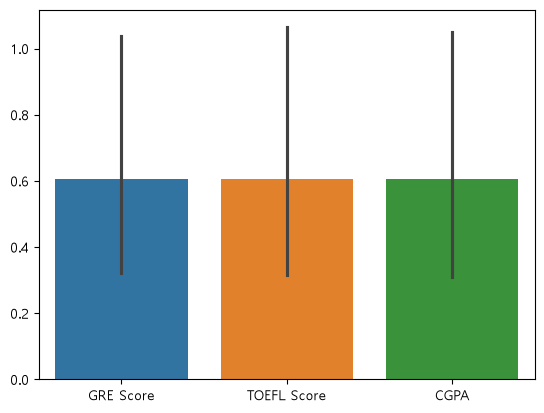

In [57]:
sns.barplot(coef_df)

In [38]:
X=admit_df.drop(columns=['Chance of Admit '])
y=admit_df['Chance of Admit ']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [40]:
scaler = StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [41]:
lr=LogisticRegression()

In [42]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [43]:
y_pred = lr.predict(X_test_scaled)

In [92]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]
y_prob_percent = y_prob * 100

for i, proba in enumerate(y_prob_percent[:20], 1):
    print(f'샘플 {i}번의 합격 확률: {proba:.2f}%')

샘플 1번의 합격 확률: 22.77%
샘플 2번의 합격 확률: 99.65%
샘플 3번의 합격 확률: 71.49%
샘플 4번의 합격 확률: 9.38%
샘플 5번의 합격 확률: 97.44%
샘플 6번의 합격 확률: 0.16%
샘플 7번의 합격 확률: 0.18%
샘플 8번의 합격 확률: 0.22%
샘플 9번의 합격 확률: 7.74%
샘플 10번의 합격 확률: 91.31%
샘플 11번의 합격 확률: 78.82%
샘플 12번의 합격 확률: 98.87%
샘플 13번의 합격 확률: 76.05%
샘플 14번의 합격 확률: 50.48%
샘플 15번의 합격 확률: 0.16%
샘플 16번의 합격 확률: 2.43%
샘플 17번의 합격 확률: 97.30%
샘플 18번의 합격 확률: 8.49%
샘플 19번의 합격 확률: 2.73%
샘플 20번의 합격 확률: 2.23%


In [44]:
lr.score(X_train_scaled, y_train)

0.871875

In [45]:
accuracy_score(y_test, y_pred)

0.9125

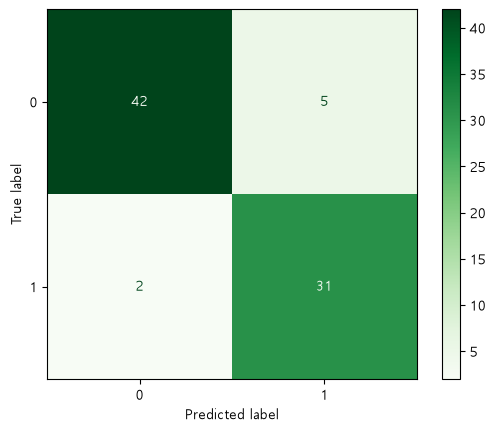

In [46]:
cm = confusion_matrix(y_pred, y_test)
display=ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap='Greens')
plt.show()

## 규제(regularization)
- 머신러닝 모델이 train 세트를 너무 과도하게 학습하지 못하도록 훼방하는 것
- 선형회귀 모델의 경우 특성에 곱해지는 계수 또는 기울기의 크기를 작게 만드는 일이다.
- 쉽게 말하자면 선형회귀 모델의 성능을 끌어올리기 위한 방법이다.
- 
#### 1) 릿지(ridge)
- 계수를 제곱한 값을 기준으로 규제를 적용한다. (일반적으로 선호)
- 조금 넘을 때는 벌금이 적지만, 과속이 심해질수록 벌금이 제곱으로 폭발하도록 설계된다.  
  즉, 작은 값으로 연산하여 값이 폭발하는 것을 방지함.
- 예를 들어 $z = (2.5 \times 100) + b = 250 + b$를
- $z = (0.008 \times 100) + b = 0.8 + b$


#### 2) 라쏘(lasso)
- 계수의 절댓값을 기준으로 규제를 적용한다. 영향을 주지 않는 가중치는 과감하게 빼버림 (가중치가 작든 크든 줄어드는 비율이 일정)
- $z = $$z = w_1 \cdot (\text{연봉}) + w_2 \cdot (\text{나이}) + w_3 \cdot (\text{성별}) + b$$
- $z = $$z = w_1 \cdot (\text{연봉}) + 0 \cdot (\text{나이}) + 0 \cdot (\text{성별}) + b$$

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [71]:
scaler = StandardScaler()

In [72]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [74]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}

result = []
coef_df = pd.DataFrame(index=X.columns)

for name, model in models.items():
    # 학습
    model.fit(X_train_scaled, y_train)

    # 예측
    y_pred = model.predict(X_test_scaled)    
    
    # 평가
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    y_pred_class = (y_pred >= 0.5).astype(int)
    acc = accuracy_score(y_test, y_pred_class)

    result.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "Acurracy": acc
    })

    coef_df[name] = model.coef_

In [75]:
result_df = pd.DataFrame(result)
result_df

,Model,MSE,RMSE,Acurracy
0,LinearRegression,0.091051,0.301747,0.9
1,Ridge,0.090987,0.301640,0.9
2,Lasso,0.092000,0.303315,0.9


In [76]:
coef_df.sort_values(by='LinearRegression', ascending=False)

,LinearRegression,Ridge,Lasso
CGPA,0.176105,0.174093,0.177582
GRE Score,0.078112,0.078168,0.077529
Research,0.076655,0.076542,0.071301
University Rating,0.042460,0.042681,0.040202
SOP,0.033585,0.033636,0.031842
TOEFL Score,0.026073,0.027174,0.022985
LOR,0.004880,0.005433,0.000906


In [82]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

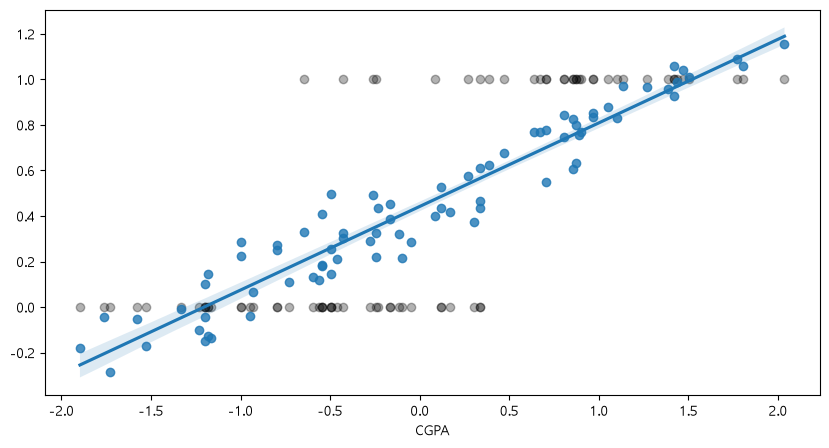

In [88]:
plt.figure(figsize=(10,5))
plt.scatter(X_test_scaled_df['CGPA'], y_test, color='black',alpha=0.3,label='Actual')
sns.regplot(x=X_test_scaled_df['CGPA'], y=model.predict(X_test_scaled))
plt.show()

In [93]:
coef_df = pd.DataFrame({
    'Features': X_train.columns,
    'Coef': lr.coef_[0]
}).sort_values(by='Coef', ascending=False)
coef_df

,Features,Coef
5,CGPA,1.882150
0,GRE Score,0.693382
1,TOEFL Score,0.450678
6,Research,0.387862
3,SOP,0.292306
4,LOR,0.272089
2,University Rating,0.268595


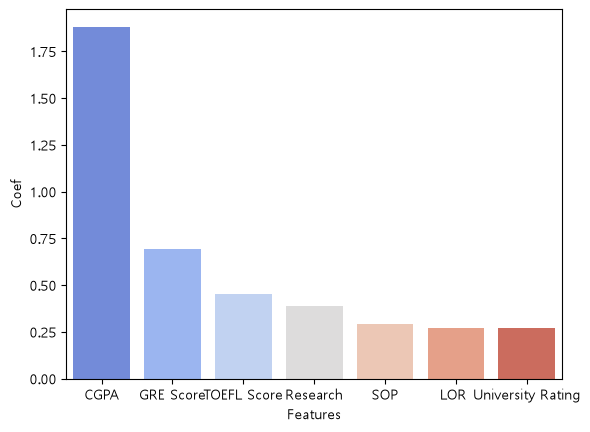

In [94]:
sns.barplot(coef_df, x='Features', y='Coef', palette='coolwarm', hue='Features')

plt.show()

In [97]:
y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.95      0.92        44
           1       0.94      0.86      0.90        36

    accuracy                           0.91        80
   macro avg       0.92      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

